In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm


In [3]:
# ------------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------------

incomes = pd.read_excel("Income_1 Counties ACS5.xlsx")
households = pd.read_excel("Total_Households Counties ACS5.xlsx")

# ------------------------------------------------------------------
# 2. CLEAN / SELECT RELEVANT COLUMNS
# Adjust column names here if needed
# ------------------------------------------------------------------

# Example expected columns:
# incomes: County Name | Year | Total | Margin of Error
# households: County Name | Year | Households

incomes = incomes.rename(columns={
    'Median Household Income': 'Income',
    'Margin of Error': 'MOE'
    
})

households = households.rename(columns={
    'Total Households': 'Households'

})
print(incomes.columns)
print(households.columns)
# ------------------------------------------------------------------
# 3. Filter Race_ethnicity to 'all'
# ------------------------------------------------------------------
incomes=incomes[incomes['Race/Ethnicity']=='All'].copy()
households=households[households['Race/Ethnicity']=='All'].copy()




Index(['State FIPS', 'MPO', 'County FIPS', 'County Name', 'NAME', 'Year',
       'Race/Ethnicity', 'Variable', 'Income', 'MOE', 'Margin of Error Ratio',
       'Use for Reporting'],
      dtype='object')
Index(['State FIPS', 'MPO', 'County FIPS', 'County Name', 'NAME', 'Year',
       'Race/Ethnicity', 'Variable', 'Households', 'Margin of Error',
       'Margin of Error Ratio', 'Use for Reporting'],
      dtype='object')


In [4]:
# ------------------------------------------------------------------
# 4. MERGE INCOME WITH HOUSEHOLD WEIGHTS
# ------------------------------------------------------------------

df = incomes.merge(
    households[['County Name', 'Year', 'Households']],
    on=['County Name', 'Year'],
    how='inner'
)

# ------------------------------------------------------------------
# 4. CONVERT MOE → SE
# ACS MOE is 90% confidence.
# SE = MOE / z 0.9
# the z score at a confidence level of 0.9 is 1.645 since its the 90% + the left side of the tail 5%
# 1.645
# ------------------------------------------------------------------
z90 = round(norm.ppf(0.95),3)
df['SE'] = df['MOE'] / z90

print("\nCounty-level data:")
print(df[['County Name', 'Income', 'SE', 'Households']])




County-level data:
   County Name  Income           SE  Households
0    El Dorado  108845  1844.984802       76185
1    El Dorado  109178  2316.717325       75719
2    El Dorado  106417  2024.316109       75190
3    El Dorado  102804  1893.009119       74535
4    El Dorado  101327  1354.407295       73078
..         ...     ...          ...         ...
88        Yuba   63394  1231.003040       24300
89        Yuba   66827  1607.294833       24133
90        Yuba   68228  1679.027356       23885
91        Yuba   70452  1716.717325       23750
92        Yuba   70614  1134.346505       24212

[93 rows x 4 columns]


![alt text](image.png)

In [5]:
# ------------------------------------------------------------------
# 5. WEIGHTED MEAN (Correct)
# ------------------------------------------------------------------

weights = df['Households']
weighted_mean = np.average(df['Income'], weights=weights)

# ------------------------------------------------------------------
# 6. CURRENT METHOD (WRONG for weighted mean)
# sqrt(sum(SE^2))
# ------------------------------------------------------------------

se_wrong_sum = np.sqrt(np.sum(df['SE']**2))

# ------------------------------------------------------------------
# 7. USER PROPOSED METHOD (ALSO WRONG)
# sqrt(sum(w * SE^2) / sum(w))
# ------------------------------------------------------------------

se_wrong_weighted = np.sqrt(np.sum(weights * df['SE']**2) / np.sum(weights))

# ------------------------------------------------------------------
# 8. CORRECT WEIGHTED SE
# sqrt( sum( (w_i / sum w)^2 * SE_i^2 ) )
# ------------------------------------------------------------------

a = weights / weights.sum()
se_correct = np.sqrt(np.sum((a**2) * (df['SE']**2)))

# Convert back to MOE for reporting
moe_correct = se_correct * 1.645




In [ ]:
# ------------------------------------------------------------------
# 9. PRINT RESULTS
# ------------------------------------------------------------------

print("\n================ RESULTS ================\n")

print(f"Weighted Mean Income: ${weighted_mean:,.2f}\n")

print("Standard Error Comparison:")
print("----------------------------------------")
print(f"Wrong (sqrt sum sq SE):       {se_wrong_sum:,.2f}")
print(f"Wrong (your proposed):        {se_wrong_weighted:,.2f}")
print(f"Correct Weighted SE:          {se_correct:,.2f}")

print("\nCorrect MPO MOE (90%):")
print(f"{moe_correct:,.2f}")


================ RESULTS ================

Weighted Mean Income: $88,553.51

Standard Error Comparison:
----------------------------------------
Wrong (sqrt sum sq SE):       12,666.99
Wrong (your proposed):        862.35
Correct Weighted SE:          88.25

Correct MPO MOE (90%):
145.17


## Extra Check that converting MOE to SE is same as Direct MOE formula

In [7]:
import numpy as np

# Example data
values = np.array([80000, 90000, 85000])
weights = np.array([10000, 15000, 12000])
moe = np.array([1000, 1200, 900])

# Normalize weights
a = weights / weights.sum()

# Method 1: Convert MOE → SE
se = moe / 1.645
se_weighted = np.sqrt(np.sum(a**2 * se**2))
moe_from_se = 1.645 * se_weighted

# Method 2: Direct MOE formula
moe_direct = np.sqrt(np.sum(a**2 * moe**2))

print("MOE via SE conversion:", round(moe_from_se, 6))
print("MOE direct formula:   ", round(moe_direct, 6))
print("Difference:", abs(moe_from_se - moe_direct))


MOE via SE conversion: 628.423422
MOE direct formula:    628.423422
Difference: 1.1368683772161603e-13


📊 ACS Margin of Error Approximation for Weighted Averages

This implementation follows guidance from:

U.S. Census Bureau (2018).
Worked Examples for Approximating Standard Errors for the American Community Survey.
https://www2.census.gov/programs-surveys/acs/tech_docs/accuracy/2018_ACS_Accuracy_Document_Worked_Examples.pdf

1️⃣ Standard Error of a Sum or Difference

The ACS states:

“The standard error of the sum of two sample estimates is the square root of the sum of the two individual standard errors squared. This can be expanded to more than two estimates by adding in the individual standard errors squared inside the radical.”
(ACS Worked Examples, pp. 4–5)

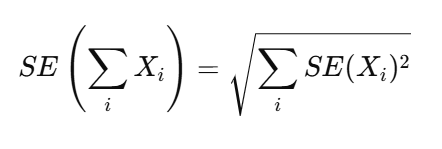


This is the variance propagation rule for independent estimates.

2️⃣ Relationship Between MOE and SE

The ACS uses a 90% confidence level and defines:
(ACS Worked Examples, p. 3)

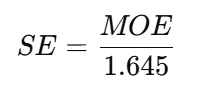


Since variance formulas use squared standard errors, the 1.645 factor cancels when squared MOEs are used directly.

3️⃣ Weighted Averages as Linear Combinations

A weighted average can be written as:

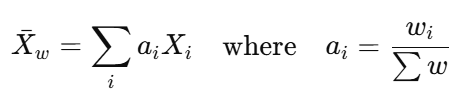
	​


For independent estimates:

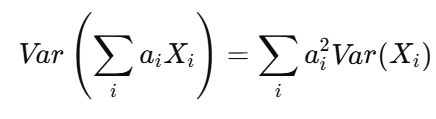

Substituting MOE directly (since variance is proportional to MOE²):

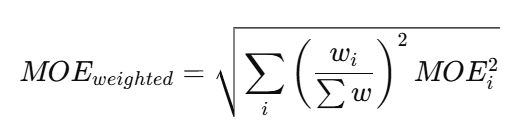


This is the formula implemented in this notebook.

🧠 Add This Section: Why You Do NOT Need to Convert to SE

Add another Markdown cell:



🔎 Why We Can Compute Weighted MOE Without Converting to SE

Starting from:

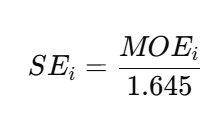

	​


Variance of weighted mean:

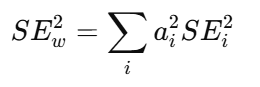
	​


Substitute:

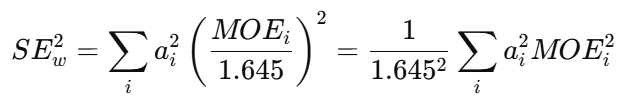


Convert back to MOE:

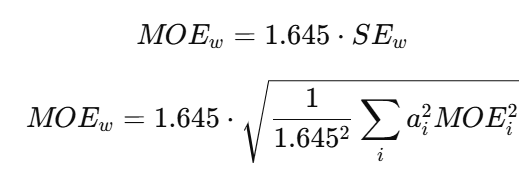

	​


The 1.645 terms cancel:

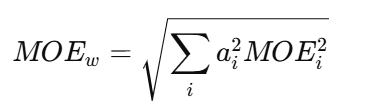
	​

	​


✅ Therefore, we can compute weighted MOE directly from MOEs without converting to SE.

Potential problem with the unincorporated margin of error formula
This is how  Unincorpoared income is calculated

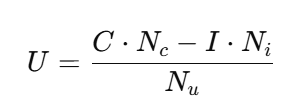

Where:

𝐶= County mean income

𝐼 = Incorporated mean income

𝑁𝑐= County households

𝑁𝑖= Incorporated households

𝑁𝑢= Unincorporated households

𝑁𝑢=𝑁𝑐−𝑁𝑖
	​


So unincorporated income is a linear combination of two independent estimates.
From the variance formula we know the linear combincation of two independeint estimates 

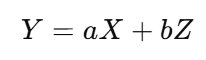

is

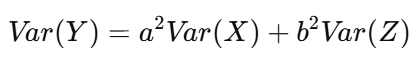

where X and Z here would be C(county income) and I(incorporated income). a and b would be Nc(county households) and Ni(incorporated households). Rewriting this 

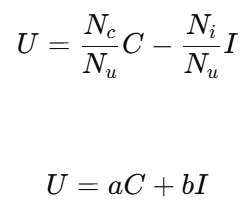

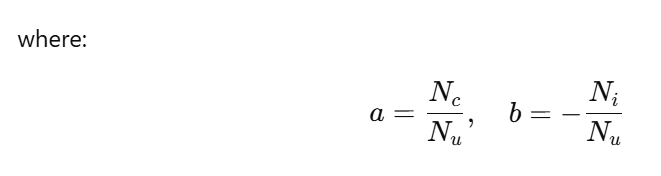

So the formula for margin of errors would be 

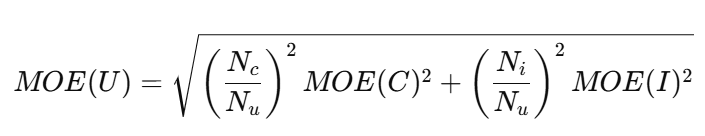


In [ ]:
def calculate_uninc_income_me(county_me,
                              county_hh,
                              incorp_me,
                              incorp_hh,
                              uninc_hh):
    try:
        term1 = (county_hh / uninc_hh)**2 * county_me**2
        term2 = (incorp_hh / uninc_hh)**2 * incorp_me**2
        return np.sqrt(term1 + term2)
    except:
        return np.nan
